In [4]:
import pandas as pd

reviews = pd.read_csv(r"C:\Users\vinee\Downloads\review-insights-main\review-insights-main\Womens Clothing E-Commerce Reviews.csv")

# Drop the rows with no review text BEFORE encoding, and keep the DataFrame
# so Rating / Department Name / Age stay lined up with every row we embed.
reviews = reviews.dropna(subset=["Review Text"])
reviews = reviews.reset_index(drop=True)

print("Reviews with text:", len(reviews))
print(reviews.head())

Reviews with text: 22641
   Unnamed: 0  Clothing ID  Age                    Title  \
0           0          767   33                      NaN   
1           1         1080   34                      NaN   
2           2         1077   60  Some major design flaws   
3           3         1049   50         My favorite buy!   
4           4          847   47         Flattering shirt   

                                         Review Text  Rating  Recommended IND  \
0  Absolutely wonderful - silky and sexy and comf...       4                1   
1  Love this dress!  it's sooo pretty.  i happene...       5                1   
2  I had such high hopes for this dress and reall...       3                0   
3  I love, love, love this jumpsuit. it's fun, fl...       5                1   
4  This shirt is very flattering to all due to th...       5                1   

   Positive Feedback Count   Division Name Department Name Class Name  
0                        0       Initmates        Intim

In [5]:
clean_texts = reviews["Review Text"].tolist()

In [6]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")

# Encode ALL reviews at once (much faster than one by one)
embeddings = model.encode(clean_texts, show_progress_bar=True)
embeddings = np.array(embeddings)

np.save("embeddings.npy", embeddings)   # so the Streamlit app doesn't re-encode every time
print("Embeddings:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/708 [00:00<?, ?it/s]

Embeddings: (22641, 384)


In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Check k instead of fixing it at 5. Text embeddings give low silhouette scores
# in general, so read these numbers together with how readable the topic words
# further down are.
for k in range(3, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(embeddings)
    score = silhouette_score(embeddings, labels, sample_size=5000, random_state=42)
    print(k, round(score, 3))

3 0.037
4 0.045
5 0.051
6 0.051
7 0.052
8 0.032
9 0.033
10 0.034


In [8]:
from sklearn.cluster import KMeans   # repeated so this cell works if the k sweep above is skipped

num_clusters = 5
kmeans_model = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
cluster_labels = kmeans_model.fit_predict(embeddings)

# Keep the labels on the DataFrame so clusters can be crossed with Rating,
# Department Name and Age.
reviews["cluster"] = cluster_labels

In [9]:
# Topic x department: which department dominates each cluster?
pd.crosstab(reviews["cluster"], reviews["Department Name"])

Department Name,Bottoms,Dresses,Intimate,Jackets,Tops,Trend
cluster,,,,,,
0,337,487,495,525,4243,29
1,628,4807,170,22,111,55
2,510,811,462,443,2822,19
3,19,26,117,8,2813,8
4,2168,14,409,4,59,7


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Fit TF-IDF ONCE on all reviews so the cluster averages are comparable.
tfidf = TfidfVectorizer(stop_words="english", min_df=5)
tfidf_matrix = tfidf.fit_transform(clean_texts)
words = tfidf.get_feature_names_out()

overall_avg = np.array(tfidf_matrix.mean(axis=0)).flatten()

In [11]:
# Words that are DISTINCTIVE to a cluster = cluster average minus overall average.
# Fitting a separate TF-IDF inside each cluster only finds words that are common
# there ("love", "great", "fit", "size" in every cluster), not words that separate it.
for cluster_num in range(num_clusters):
    positions = reviews[reviews["cluster"] == cluster_num].index
    cluster_avg = np.array(tfidf_matrix[positions].mean(axis=0)).flatten()

    difference = cluster_avg - overall_avg
    top_positions = np.argsort(difference)[-10:][::-1]

    top_words = []
    for pos in top_positions:
        top_words.append(words[pos])

    print("Cluster", cluster_num, "→", top_words)

Cluster 0 → ['sweater', 'shirt', 'soft', 'color', 'blouse', 'piece', 'jacket', 'tee', 'warm', 'cardigan']
Cluster 1 → ['dress', 'skirt', 'dresses', 'slip', 'beautiful', 'wedding', 'waist', 'knee', 'flattering', 'fabric']
Cluster 2 → ['small', 'xs', 'size', 'medium', 'large', 'ordered', 'petite', 'fits', 'lbs', 'shirt']
Cluster 3 → ['tops', 'cute', 'love', 'boxy', 'looks', 'sheer', 'pretty', 'tank', 'peplum', 'cami']
Cluster 4 → ['pants', 'jeans', 'pair', 'fit', 'stretch', 'shorts', 'pilcro', 'legs', 'comfortable', 'ankle']


In [12]:
# Named from the distinctive words above - re-read those words if you change k
# or drop n_init, because the cluster numbering moves with them.
cluster_names = {
    0: "Sweaters & Shirts",
    1: "Dresses & Skirts",
    2: "Sizing & Ordering",
    3: "Casual Tops & Tanks",
    4: "Pants & Jeans"
}

for cluster_num in range(num_clusters):
    count = (cluster_labels == cluster_num).sum()
    print(cluster_names[cluster_num], "→", count, "reviews")

Sweaters & Shirts → 6119 reviews
Dresses & Skirts → 5793 reviews
Sizing & Ordering → 5068 reviews
Casual Tops & Tanks → 2991 reviews
Pants & Jeans → 2670 reviews


In [13]:
import umap

# UMAP is only for the picture. KMeans above ran on the full 384 dimensions.
reducer = umap.UMAP(n_components=2, random_state=42)
embeddings_2d = reducer.fit_transform(embeddings)

D:\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


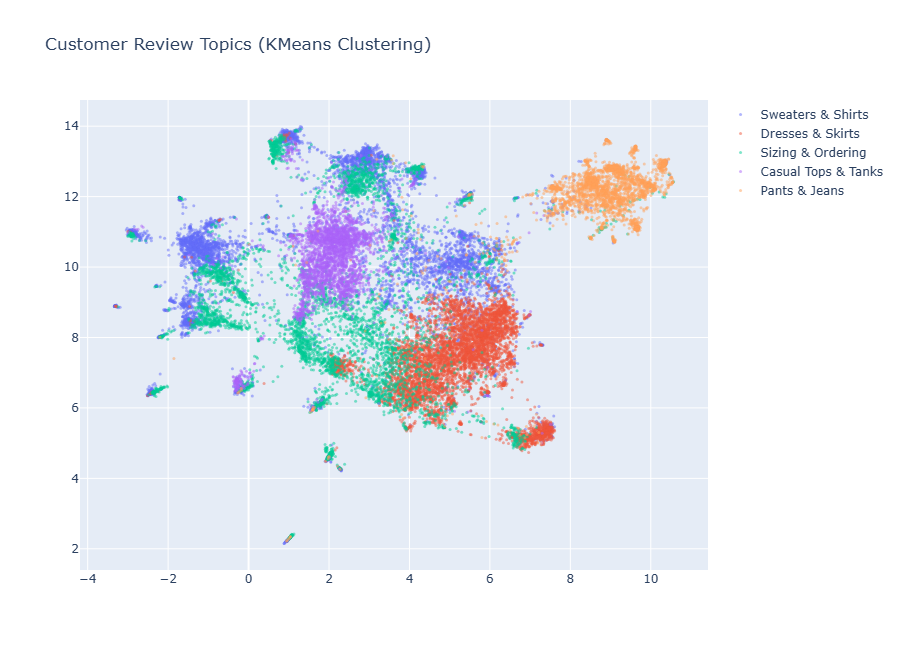

In [14]:
import plotly.graph_objects as go

fig = go.Figure()

for cluster_num in range(num_clusters):

    cluster_x = []
    cluster_y = []
    cluster_text = []

    for i in range(len(cluster_labels)):
        if cluster_labels[i] == cluster_num:
            cluster_x.append(embeddings_2d[i, 0])
            cluster_y.append(embeddings_2d[i, 1])
            short_text = clean_texts[i][:100]
            cluster_text.append(short_text)

    fig.add_trace(go.Scatter(
        x=cluster_x,
        y=cluster_y,
        mode="markers",
        marker=dict(size=3, opacity=0.5),
        name=cluster_names[cluster_num],
        text=cluster_text,
        hoverinfo="text+name"
    ))

fig.update_layout(
    title="Customer Review Topics (KMeans Clustering)",
    width=900,
    height=650,
    legend=dict(font=dict(size=12))
)

fig.show()

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

input_review = "the dress runs small, had to size up"
input_vector = model.encode([input_review])

# One call on the whole matrix, not one call per review.
similarities = cosine_similarity(input_vector, embeddings)[0]
top5 = np.argsort(similarities)[::-1][:5]   # best match first

for i in top5:
    print(round(similarities[i], 3), "|", reviews.loc[i, "Department Name"], "| Rating:", reviews.loc[i, "Rating"])
    print(clean_texts[i])
    print("---")

0.81 | Dresses | Rating: 2
The dress is too loose and runs too big
---
0.79 | Dresses | Rating: 3
I loved the style and shape of the dress . it does run small. i had to return it because some of the black dots pulled and looked like it might be more of a problem as i wore it
---
0.781 | Dresses | Rating: 4
This dress runs waaaay small. i would have too size up at least 2 sizes. while it is a beautiful color, it is an extremely stiff dress. returning!
---
0.775 | Dresses | Rating: 5
This dress looks great with bright color, but size runs small.
---
0.764 | Dresses | Rating: 4
Lovely dress but runs at least a full size too big.
---


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Clustering, topic words and similarity search are unsupervised - there is no
# label to cheat on, so they use all the data. Logistic regression learns from
# labels, so it has to be scored on reviews it never saw. stratify=y because
# 55% of the reviews are 5 star.
y = reviews["Rating"]

X_train, X_test, y_train, y_test = train_test_split(
    embeddings, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", len(X_train), " Test:", len(X_test))

baseline = (y_test == 5).mean()
print("Always guessing 5 stars gives accuracy:", round(baseline, 3))

Train: 18112  Test: 4529
Always guessing 5 stars gives accuracy: 0.554


In [17]:
# class_weight="balanced" stops the model from simply predicting 5 stars every
# time. Accuracy alone hides that, which is why macro F1 (in the report) and the
# confusion matrix go next to it.
lr_model = LogisticRegression(max_iter=2000, class_weight="balanced")
lr_model.fit(X_train, y_train)
predictions = lr_model.predict(X_test)

print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))

              precision    recall  f1-score   support

           1       0.18      0.48      0.26       164
           2       0.23      0.34      0.28       310
           3       0.30      0.28      0.29       565
           4       0.35      0.38      0.37       982
           5       0.81      0.65      0.72      2508

    accuracy                           0.52      4529
   macro avg       0.37      0.43      0.38      4529
weighted avg       0.58      0.52      0.54      4529

[[  79   48   26    6    5]
 [  86  105   79   30   10]
 [  92  151  161  116   45]
 [  72   64  143  376  327]
 [ 109   80  129  550 1640]]


In [18]:
# Same model on TF-IDF features. Split the TEXT first, then fit_transform on
# train and transform on test - fitting the vectorizer on everything leaks test
# vocabulary into training.
text_train, text_test, y_train_t, y_test_t = train_test_split(
    clean_texts, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(stop_words="english", min_df=5)
X_train_tfidf = vectorizer.fit_transform(text_train)
X_test_tfidf = vectorizer.transform(text_test)

lr_tfidf = LogisticRegression(max_iter=2000, class_weight="balanced")
lr_tfidf.fit(X_train_tfidf, y_train_t)
pred_tfidf = lr_tfidf.predict(X_test_tfidf)

print(classification_report(y_test_t, pred_tfidf))

              precision    recall  f1-score   support

           1       0.24      0.41      0.31       164
           2       0.24      0.31      0.27       310
           3       0.33      0.36      0.34       565
           4       0.38      0.43      0.41       982
           5       0.83      0.71      0.77      2508

    accuracy                           0.57      4529
   macro avg       0.41      0.44      0.42      4529
weighted avg       0.61      0.57      0.58      4529



In [19]:
# Recommended IND is the clearest signal in the text, so it is the headline
# prediction target and the 5 star task stays as the harder one. Neighbouring
# ratings are genuinely ambiguous: plenty of 3 star reviews still recommend
# the product.
rec = reviews["Recommended IND"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    embeddings, rec, test_size=0.2, random_state=42, stratify=rec
)

rec_model = LogisticRegression(max_iter=2000, class_weight="balanced")
rec_model.fit(Xr_train, yr_train)
rec_pred = rec_model.predict(Xr_test)

print("Majority baseline:", round((yr_test == 1).mean(), 3))
print(classification_report(yr_test, rec_pred))
print(confusion_matrix(yr_test, rec_pred))

Majority baseline: 0.819
              precision    recall  f1-score   support

           0       0.49      0.80      0.61       820
           1       0.95      0.82      0.88      3709

    accuracy                           0.81      4529
   macro avg       0.72      0.81      0.74      4529
weighted avg       0.87      0.81      0.83      4529

[[ 656  164]
 [ 684 3025]]


In [20]:
# Words (TF-IDF) vs meaning (embeddings): same model, same split, both targets.
def score_model(setup, X_tr, X_te, y_tr, y_te, baseline):
    m = LogisticRegression(max_iter=2000, class_weight="balanced")
    m.fit(X_tr, y_tr)
    p = m.predict(X_te)
    return {
        "setup": setup,
        "accuracy": round(accuracy_score(y_te, p), 3),
        "macro_f1": round(f1_score(y_te, p, average="macro"), 3),
        "majority_baseline": round(baseline, 3)
    }

text_train_r, text_test_r, yr_train_t, yr_test_t = train_test_split(
    clean_texts, rec, test_size=0.2, random_state=42, stratify=rec
)
vec_rec = TfidfVectorizer(stop_words="english", min_df=5)
Xr_train_tfidf = vec_rec.fit_transform(text_train_r)
Xr_test_tfidf = vec_rec.transform(text_test_r)

rows = [
    score_model("rating 5-class, embeddings", X_train, X_test, y_train, y_test, (y_test == 5).mean()),
    score_model("rating 5-class, TF-IDF", X_train_tfidf, X_test_tfidf, y_train_t, y_test_t, (y_test_t == 5).mean()),
    score_model("recommended, embeddings", Xr_train, Xr_test, yr_train, yr_test, (yr_test == 1).mean()),
    score_model("recommended, TF-IDF", Xr_train_tfidf, Xr_test_tfidf, yr_train_t, yr_test_t, (yr_test_t == 1).mean())
]

pd.DataFrame(rows)

,setup,accuracy,macro_f1,majority_baseline
0,"rating 5-class, embeddings",0.521,0.384,0.554
1,"rating 5-class, TF-IDF",0.567,0.418,0.554
2,"recommended, embeddings",0.813,0.742,0.819
3,"recommended, TF-IDF",0.862,0.799,0.819


In [21]:
# Honesty check: did KMeans find topics, or did it just rediscover Department Name?
# Read down each row - a row dominated by one department means that cluster IS
# that department. Sentence-level aspects further down are the fix for this.
pd.crosstab(reviews["cluster"], reviews["Department Name"], normalize="index").round(2)

Department Name,Bottoms,Dresses,Intimate,Jackets,Tops,Trend
cluster,,,,,,
0,0.06,0.08,0.08,0.09,0.69,0.00
1,0.11,0.83,0.03,0.00,0.02,0.01
2,0.10,0.16,0.09,0.09,0.56,0.00
3,0.01,0.01,0.04,0.00,0.94,0.00
4,0.81,0.01,0.15,0.00,0.02,0.00


In [22]:
# Titles like "Runs small!" are strong signals, so keep them as a separate
# feature set. Note that embedding full_text instead of Review Text would move
# the cluster numbering again, and the cluster names would need re-deriving.
reviews["full_text"] = reviews["Title"].fillna("") + ". " + reviews["Review Text"]
full_texts = reviews["full_text"].tolist()

print(full_texts[1][:160])

. Love this dress!  it's sooo pretty.  i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite.  i bought a 


In [23]:
import re
from gensim.models import Word2Vec

tokenized_reviews = []
for text in clean_texts:
    words = re.findall(r"[a-z']+", text.lower())
    tokenized_reviews.append(words)

w2v_model = Word2Vec(tokenized_reviews, vector_size=100, window=5, min_count=5, seed=42, epochs=10)
print("Vocabulary:", len(w2v_model.wv))

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocabulary: 4849


In [24]:
# What Word2Vec learned. Useful for vocabulary discovery - most_similar("itchy")
# hands you a complaint word list for the aspect descriptions below.
for word in ["snug", "xs", "flimsy", "returned", "gorgeous", "itchy", "sheer"]:
    print(word, "\u2192", [w for w, score in w2v_model.wv.most_similar(word, topn=6)])

snug → ['tight', 'roomy', 'loose', 'baggy', 'big', 'large']
xs → ['xsp', 'xxsp', 'xxs', 'm', 'xl', 'medium']
flimsy → ['scratchy', 'rough', 'stiff', 'polyester', 'rayon', 'cheap']
returned → ['kept', 'return', 'exchanged', 'returning', 'knew', 'grabbed']
gorgeous → ['beautiful', 'lovely', 'stunning', 'darling', 'adorable', 'pretty']
itchy → ['scratchy', 'stiff', 'rough', 'flimsy', 'thin', 'bulky']
sheer → ['transparent', 'thin', 'noticeable', 'scratchy', 'itchy', 'opaque']


In [25]:
# Averaging word vectors gives one vector per review - but note what the list
# above shows: "snug" sits next to "loose" and "returned" next to "kept", because
# Word2Vec learns from context and opposites share contexts. Averaging therefore
# cancels out part of the sentiment, which is visible in the table further down.
w2v_review_vectors = []
for words in tokenized_reviews:
    word_vectors = []
    for w in words:
        if w in w2v_model.wv:
            word_vectors.append(w2v_model.wv[w])
    if len(word_vectors) > 0:
        w2v_review_vectors.append(np.mean(word_vectors, axis=0))
    else:
        w2v_review_vectors.append(np.zeros(100))

w2v_review_vectors = np.array(w2v_review_vectors)
print(w2v_review_vectors.shape)

(22641, 100)


In [26]:
# The progression that matters for the write-up: TF-IDF -> +Title -> Word2Vec -> MiniLM,
# all on Recommended IND, all on the same stratified 80/20 split.
def fit_and_score(setup, X_tr, X_te, y_tr, y_te):
    m = LogisticRegression(max_iter=2000, class_weight="balanced")
    m.fit(X_tr, y_tr)
    p = m.predict(X_te)
    row = {
        "setup": setup,
        "accuracy": round(accuracy_score(y_te, p), 3),
        "macro_f1": round(f1_score(y_te, p, average="macro"), 3)
    }
    return row, m

progression = []

# words
text_train, text_test, r_train, r_test = train_test_split(
    clean_texts, rec, test_size=0.2, random_state=42, stratify=rec
)
rec_vectorizer = TfidfVectorizer(stop_words="english", min_df=5)
row, rec_word_model = fit_and_score(
    "TF-IDF, review text",
    rec_vectorizer.fit_transform(text_train), rec_vectorizer.transform(text_test),
    r_train, r_test
)
progression.append(row)

# words + title
full_train, full_test, rf_train, rf_test = train_test_split(
    full_texts, rec, test_size=0.2, random_state=42, stratify=rec
)
title_vectorizer = TfidfVectorizer(stop_words="english", min_df=5)
row, _ = fit_and_score(
    "TF-IDF, title + review",
    title_vectorizer.fit_transform(full_train), title_vectorizer.transform(full_test),
    rf_train, rf_test
)
progression.append(row)

# averaged word vectors
w2v_train, w2v_test, rw_train, rw_test = train_test_split(
    w2v_review_vectors, rec, test_size=0.2, random_state=42, stratify=rec
)
row, _ = fit_and_score("Word2Vec, averaged", w2v_train, w2v_test, rw_train, rw_test)
progression.append(row)

# sentence embeddings
row, _ = fit_and_score("MiniLM embeddings", Xr_train, Xr_test, yr_train, yr_test)
progression.append(row)

print("Majority baseline:", round((r_test == 1).mean(), 3))
pd.DataFrame(progression)

Majority baseline: 0.819


,setup,accuracy,macro_f1
0,"TF-IDF, review text",0.862,0.799
1,"TF-IDF, title + review",0.880,0.822
2,"Word2Vec, averaged",0.824,0.760
3,MiniLM embeddings,0.813,0.742


In [27]:
# Why the model said what it said. With TF-IDF features every coefficient is a
# word, so the model explains itself for free.
coefficients = rec_word_model.coef_[0]
feature_words = rec_vectorizer.get_feature_names_out()

print("Pushes toward NOT recommended:")
for i in np.argsort(coefficients)[:15]:
    print("  ", feature_words[i], round(coefficients[i], 2))

print("\nPushes toward recommended:")
for i in np.argsort(coefficients)[-15:][::-1]:
    print("  ", feature_words[i], round(coefficients[i], 2))

Pushes toward NOT recommended:
   disappointed -5.7
   wanted -5.07
   returning -4.63
   returned -4.61
   cheap -4.13
   unflattering -3.65
   huge -3.65
   excited -3.63
   bad -3.54
   unfortunately -3.5
   poor -3.32
   fabric -3.23
   return -3.23
   looked -3.14
   shame -3.07

Pushes toward recommended:
   love 6.24
   perfect 5.54
   comfortable 4.72
   great 4.52
   little 4.48
   compliments 4.37
   fits 4.28
   perfectly 3.79
   unique 3.61
   glad 3.55
   soft 3.4
   happy 3.32
   nicely 3.25
   dressed 3.19
   comfy 3.15


In [28]:
# Aspect-based sentiment. One overall label per review hides that a reviewer can
# love the color and hate the fit, and review-level clusters group by product
# type. Sentences are where the themes actually live.
aspects = {
    "Fit & Size": "the size and fit, runs small or large, tight or loose",
    "Fabric & Quality": "the fabric and material, thin, soft, itchy, see through",
    "Color": "the color and print of the item",
    "Length": "the length, too long or too short, hits at the knee",
    "Price": "the price and value for money, expensive, on sale",
    "Comfort": "how comfortable it is to wear"
}
aspect_names = list(aspects.keys())
aspect_vectors = model.encode(list(aspects.values()))

# Sanity check on one review before running the whole dataset
for sentence in re.split(r"[.!?]", clean_texts[2]):
    sentence = sentence.strip()
    if sentence:
        scores = cosine_similarity(model.encode([sentence]), aspect_vectors)[0]
        best = np.argmax(scores)
        print(aspect_names[best], "|", round(scores[best], 3), "|", sentence)

Comfort | 0.312 | I had such high hopes for this dress and really wanted it to work for me
Fit & Size | 0.445 | i initially ordered the petite small (my usual size) but i found this to be outrageously small
Length | 0.189 | so small in fact that i could not zip it up
Fit & Size | 0.376 | i reordered it in petite medium, which was just ok
Comfort | 0.369 | overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat cheap (net) over layers
Fabric & Quality | 0.218 | imo, a major design flaw was the net over layer sewn directly into the zipper - it c


In [29]:
import os

sentence_rows = []
for row_position in range(len(clean_texts)):
    for sentence in re.split(r"[.!?]", clean_texts[row_position]):
        sentence = sentence.strip()
        if len(sentence) > 3:
            sentence_rows.append((row_position, sentence))

sentences = [s for _, s in sentence_rows]
print("Sentences:", len(sentences), "from", len(clean_texts), "reviews")

# ~112,000 sentences. They are short, so this runs in about 4 minutes on CPU -
# much faster than the 22,641 full reviews - but only because they go through in
# ONE batch. Encoding them one at a time would take days. Cached either way; the
# file is ~170 MB.
SENTENCE_CACHE = "sentence_embeddings.npy"

if os.path.exists(SENTENCE_CACHE) and len(np.load(SENTENCE_CACHE, mmap_mode="r")) == len(sentences):
    sentence_embeddings = np.load(SENTENCE_CACHE)
    print("Loaded cached sentence embeddings")
else:
    sentence_embeddings = np.array(model.encode(sentences, show_progress_bar=True, batch_size=128))
    np.save(SENTENCE_CACHE, sentence_embeddings)

print(sentence_embeddings.shape)

Sentences: 111864 from 22641 reviews


Batches:   0%|          | 0/874 [00:00<?, ?it/s]

(111864, 384)


In [30]:
aspect_similarity = cosine_similarity(sentence_embeddings, aspect_vectors)
best_aspect = aspect_similarity.argmax(axis=1)
best_aspect_score = aspect_similarity.max(axis=1)

# Cutoff read off the score distribution: the median sentence scores about 0.33,
# and 0.25 keeps roughly three quarters of sentences. Weaker matches are chit-chat
# ("i am 5'4 and 130 lbs", "bought this for a wedding") and become "Other".
ASPECT_CUTOFF = 0.25

sentence_df = pd.DataFrame({
    "review_row": [r for r, s in sentence_rows],
    "sentence": sentences,
    "aspect": [aspect_names[b] for b in best_aspect],
    "aspect_score": best_aspect_score
})
sentence_df.loc[sentence_df["aspect_score"] < ASPECT_CUTOFF, "aspect"] = "Other"

sentence_df["Department Name"] = reviews["Department Name"].reindex(sentence_df["review_row"]).values
sentence_df["Clothing ID"] = reviews["Clothing ID"].reindex(sentence_df["review_row"]).values

print(sentence_df["aspect"].value_counts())

aspect
Comfort             30168
Other               28715
Fit & Size          19873
Color               11119
Fabric & Quality    10901
Length               8217
Price                2871
Name: count, dtype: int64


In [31]:
# Sentiment per sentence, scored with the project's own recommender: the
# probability that a review containing this sentence is a recommendation.
# (VADER is the off-the-shelf alternative - SentimentIntensityAnalyzer().
# polarity_scores(sentence)["compound"] - at the cost of another dependency.)
sentence_df["sentiment"] = rec_word_model.predict_proba(
    rec_vectorizer.transform(sentences)
)[:, 1]

print(sentence_df.groupby("aspect")["sentiment"].agg(["mean", "count"]).round(3).sort_values("mean"))

# Known weakness of this scorer: it was trained on whole reviews, so it keys on
# words like "disappointed" and "returned". Per-aspect MEANS are informative
# (Length and Fabric are clearly the weak spots), but the single most negative
# sentence in any aspect tends to be a generic complaint. VADER, or a model
# trained on sentences, would sharpen the per-sentence end of this.

                   mean  count
aspect                        
Length            0.471   8217
Fabric & Quality  0.476  10901
Other             0.534  28715
Price             0.542   2871
Color             0.640  11119
Fit & Size        0.640  19873
Comfort           0.666  30168


In [32]:
import plotly.express as px

# The payoff: which aspect goes wrong in which department.
heatmap_data = sentence_df[sentence_df["aspect"] != "Other"].pivot_table(
    index="aspect", columns="Department Name", values="sentiment", aggfunc="mean"
)

fig_heat = px.imshow(
    heatmap_data.round(2),
    text_auto=True,
    color_continuous_scale="RdYlGn",
    aspect="auto",
    title="Mean sentiment by aspect and department (red = where the complaints are)"
)
fig_heat.update_layout(width=900, height=450)
fig_heat.show()

In [33]:
# The most negative sentences per aspect - the actual complaints behind the heatmap.
for aspect_name in aspect_names:
    print("###", aspect_name)
    worst = sentence_df[sentence_df["aspect"] == aspect_name].nsmallest(3, "sentiment")
    for _, r in worst.iterrows():
        print("  ", round(r["sentiment"], 3), "|", r["sentence"][:100])

### Fit & Size
   0.005 | they ran very small and the fabric seemed cheap for the price
   0.006 | I was so excited to try these but was really disappointed in the fit
   0.006 | these are not cheap pants, so the poor quality is inexcusable
### Fabric & Quality
   0.002 | Fabric felt and looked cheap
   0.002 | i am returning it as it is very thin and the quality is cheap looking
   0.002 | it also felt rather cheap & scratchy, poor quality for the price
### Color
   0.003 | unfortunately this shirt had to be returned
   0.004 | so disappointed in the quality and the labeling
   0.004 | am so disappointed in the quality
### Length
   0.001 | the shape was awful, but looked like a sack - returned
   0.005 | unfortunately, this fell short as it was huge
   0.005 | unfortunately it made me look huge
### Price
   0.002 | i thought it looked cheap
   0.003 | for the price of the shirt, i thought the buttons looked cheap
   0.004 | it just looked and felt cheap
### Comfort
   0.001 | I had h

In [34]:
# Fit language: what a shopper actually wants to know before ordering.
review_text_lower = reviews["Review Text"].str.lower()

for phrase in ["true to size", "size down", "size up", "runs large", "runs small", "too small", "too big"]:
    print(phrase, "\u2192", review_text_lower.str.contains(phrase).sum())

SIZE_UP_PATTERN = r"size up|runs small|too small|too tight"
SIZE_DOWN_PATTERN = r"size down|runs large|runs big|too big|too large"

reviews["says_size_up"] = review_text_lower.str.contains(SIZE_UP_PATTERN, regex=True)
reviews["says_size_down"] = review_text_lower.str.contains(SIZE_DOWN_PATTERN, regex=True)
reviews["says_true_to_size"] = review_text_lower.str.contains("true to size")

true to size → 1287
size down → 659
size up → 488
runs large → 274
runs small → 228
too small → 224
too big → 558


In [35]:
# Enough reviews per product to say something: 165 products have 20 or more,
# and they cover 86% of all reviews.
product_counts = reviews["Clothing ID"].value_counts()
big_products = product_counts[product_counts >= 20].index

coverage = reviews["Clothing ID"].isin(big_products).mean()
print("Products with 20+ reviews:", len(big_products), "covering", round(coverage, 3), "of reviews")


def fit_verdict(row):
    if row["size_up"] > row["size_down"] and row["size_up"] > row["true_to_size"]:
        return "Runs small - size up"
    if row["size_down"] > row["size_up"] and row["size_down"] > row["true_to_size"]:
        return "Runs large - size down"
    return "True to size"


fit_report = reviews[reviews["Clothing ID"].isin(big_products)].groupby("Clothing ID").agg(
    n_reviews=("Review Text", "count"),
    avg_rating=("Rating", "mean"),
    recommend_rate=("Recommended IND", "mean"),
    size_up=("says_size_up", "sum"),
    size_down=("says_size_down", "sum"),
    true_to_size=("says_true_to_size", "sum")
)

fit_report["verdict"] = fit_report.apply(fit_verdict, axis=1)
fit_report["avg_rating"] = fit_report["avg_rating"].round(2)
fit_report["recommend_rate"] = fit_report["recommend_rate"].round(2)

# Weakest aspect per product, straight from the sentence table
weakest = (sentence_df[sentence_df["aspect"] != "Other"]
           .groupby(["Clothing ID", "aspect"])["sentiment"].mean()
           .reset_index()
           .sort_values("sentiment")
           .groupby("Clothing ID").first())
fit_report["weakest_aspect"] = weakest["aspect"]

print(fit_report["verdict"].value_counts())
fit_report.sort_values("n_reviews", ascending=False).head(10)

Products with 20+ reviews: 165 covering 0.862 of reviews
verdict
Runs large - size down    75
True to size              59
Runs small - size up      31
Name: count, dtype: int64


,n_reviews,avg_rating,recommend_rate,size_up,size_down,true_to_size,verdict,weakest_aspect
Clothing ID,,,,,,,,
1078,987,4.19,0.82,58,74,52,Runs large - size down,Fabric & Quality
862,778,4.19,0.82,30,62,51,Runs large - size down,Length
1094,735,4.19,0.82,55,45,41,Runs small - size up,Fabric & Quality
1081,561,4.27,0.84,23,39,30,Runs large - size down,Length
872,519,4.37,0.87,20,31,20,Runs large - size down,Fabric & Quality
829,512,4.19,0.83,34,42,23,Runs large - size down,Fabric & Quality
1110,471,4.27,0.84,34,45,38,Runs large - size down,Length
868,414,3.93,0.75,16,54,21,Runs large - size down,Fabric & Quality
895,384,4.27,0.84,8,17,21,True to size,Length
